# Laboratorio 4 – Filtro Bayer y Transformaciones YUV

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [15, 5]

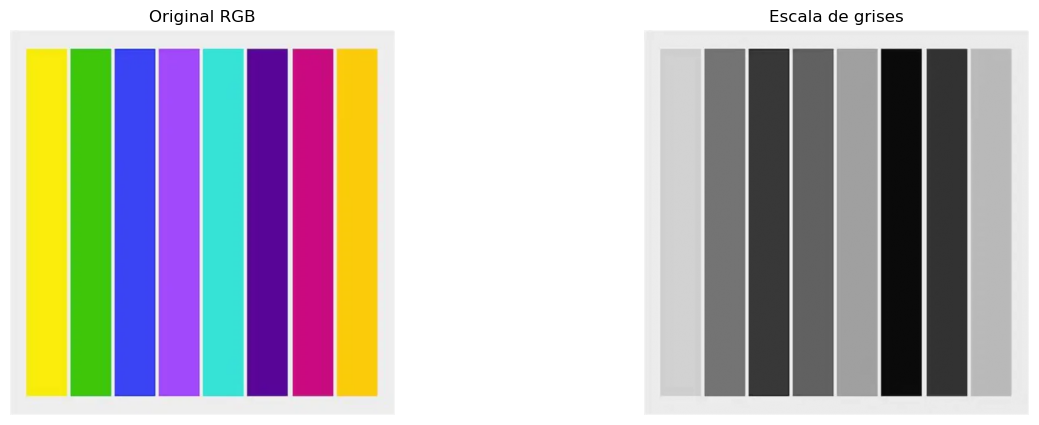

In [8]:
img = cv2.cvtColor(cv2.imread('colores.jpg'), cv2.COLOR_BGR2RGB)
img_gris = cv2.imread('colores.jpg', cv2.IMREAD_GRAYSCALE)

plt.subplot(121)  
plt.title('Original RGB')
plt.imshow(img) 
plt.axis('off')

plt.subplot(122) 
plt.title('Escala de grises')
plt.imshow(img_gris, cmap='gray')
plt.axis('off')

plt.show()

## Parte 1 – Filtro Bayer (4 versiones en cv2)

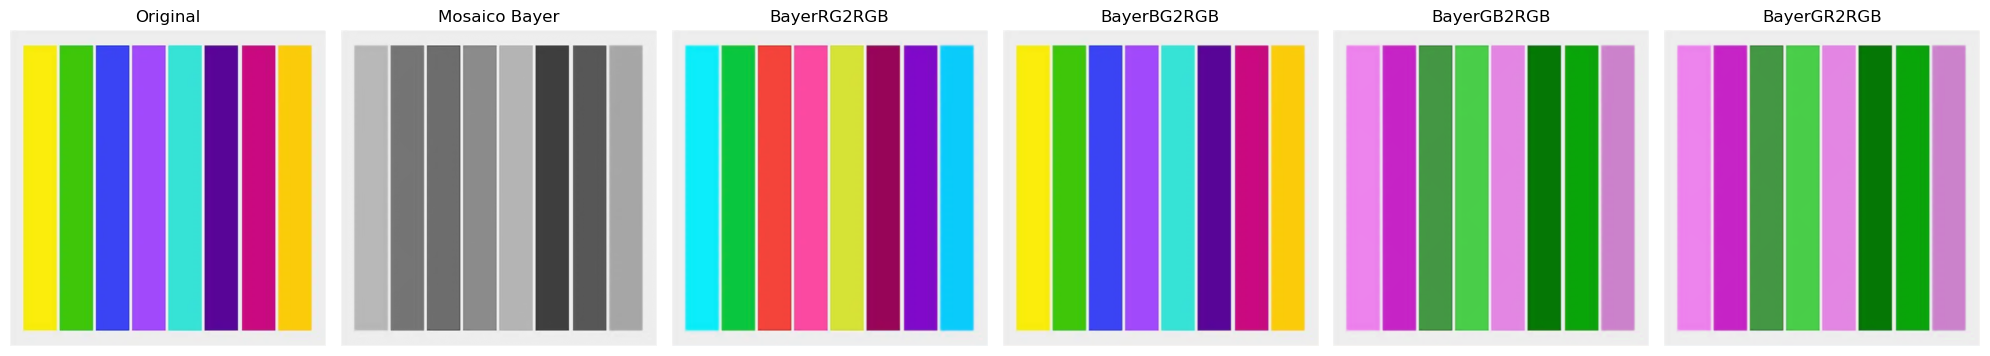

In [9]:
h, w, _ = img.shape

# Crear mosaico Bayer RGGB 
# Patrón:  R G
#          G B
bayer_rg = np.zeros((h, w), dtype=np.uint8)
bayer_rg[0::2, 0::2] = img[0::2, 0::2, 0]  # R en (par, par) 
bayer_rg[0::2, 1::2] = img[0::2, 1::2, 1]  # G en (par, impar)
bayer_rg[1::2, 0::2] = img[1::2, 0::2, 1]  # G en (impar, par)
bayer_rg[1::2, 1::2] = img[1::2, 1::2, 2]  # B en (impar, impar)

# Demosaicing con las 4 versiones
rec_RG = cv2.cvtColor(bayer_rg, cv2.COLOR_BayerRG2RGB)
rec_BG = cv2.cvtColor(bayer_rg, cv2.COLOR_BayerBG2RGB)
rec_GB = cv2.cvtColor(bayer_rg, cv2.COLOR_BayerGB2RGB)
rec_GR = cv2.cvtColor(bayer_rg, cv2.COLOR_BayerGR2RGB)

plt.figure(figsize=(20, 4))

plt.subplot(161)
plt.title('Original')
plt.imshow(img)
plt.axis('off')

plt.subplot(162)
plt.title('Mosaico Bayer')
plt.imshow(bayer_rg, cmap='gray')
plt.axis('off')

plt.subplot(163)
plt.title('BayerRG2RGB')
plt.imshow(rec_RG)
plt.axis('off')

plt.subplot(164)
plt.title('BayerBG2RGB')
plt.imshow(rec_BG)
plt.axis('off')

plt.subplot(165)
plt.title('BayerGB2RGB')
plt.imshow(rec_GB)
plt.axis('off')

plt.subplot(166)
plt.title('BayerGR2RGB')
plt.imshow(rec_GR)
plt.axis('off')

plt.tight_layout()
plt.show()

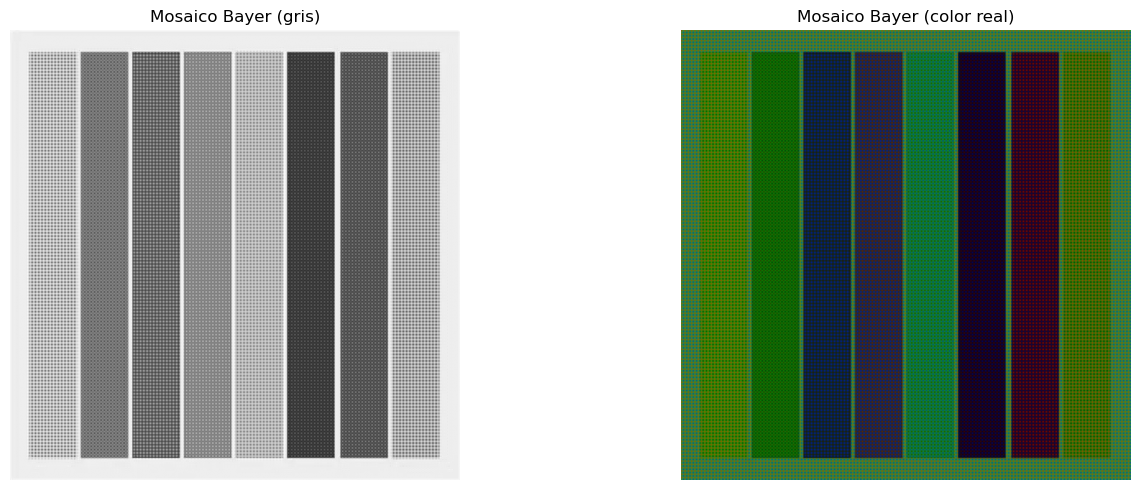

In [ ]:
# Visualizar mosaico Bayer con colores reales (R=rojo, G=verde, B=azul)
bayer_color = np.zeros((h, w, 3), dtype=np.uint8)

bayer_color[0::2, 0::2, 0] = img[0::2, 0::2, 0]  # R en rojitou
bayer_color[0::2, 1::2, 1] = img[0::2, 1::2, 1]  # G en verd
bayer_color[1::2, 0::2, 1] = img[1::2, 0::2, 1]  # G en verde
bayer_color[1::2, 1::2, 2] = img[1::2, 1::2, 2]  # B en azulitou

plt.subplot(121)
plt.title('Mosaico Bayer (gris)')
plt.imshow(bayer_rg, cmap='gray')
plt.axis('off')

plt.subplot(122)
plt.title('Mosaico Bayer (color real)')
plt.imshow(bayer_color)
plt.axis('off')

plt.tight_layout()
plt.show()

## Visualización del Mosaico Bayer con Colores Reales


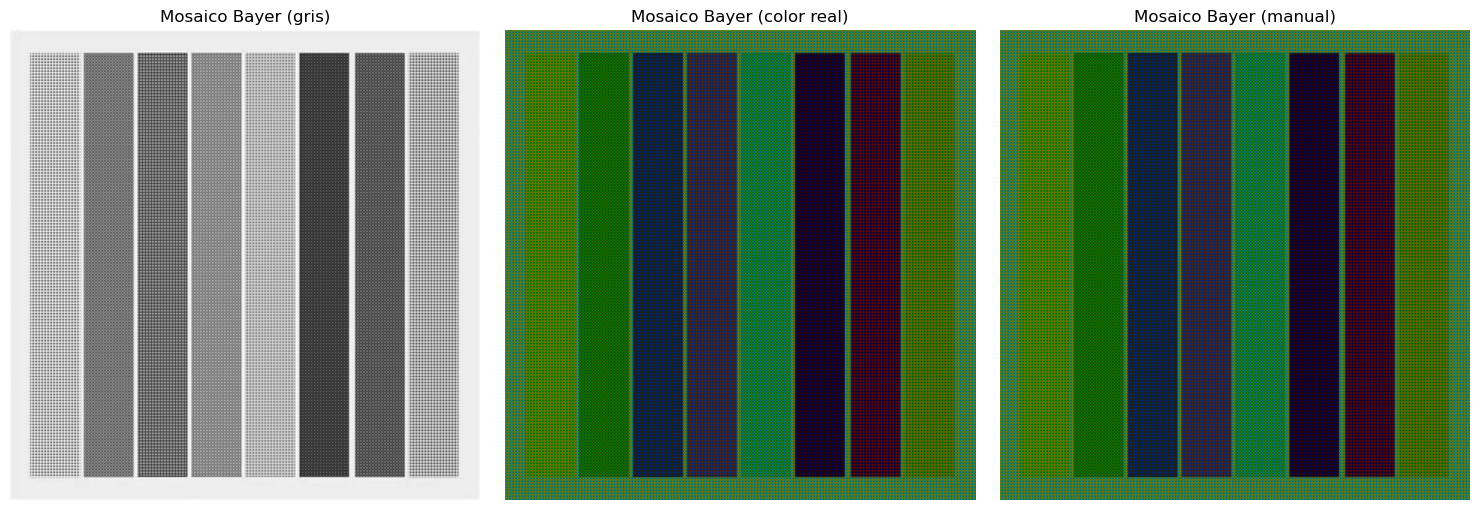

In [13]:
# Mosaico Bayer con colores reales
bayer_color = np.zeros((h, w, 3), dtype=np.uint8)

bayer_color[0::2, 0::2, 0] = img[0::2, 0::2, 0]  # R en rojo
bayer_color[0::2, 1::2, 1] = img[0::2, 1::2, 1]  # G en verde
bayer_color[1::2, 0::2, 1] = img[1::2, 0::2, 1]  # G en verde
bayer_color[1::2, 1::2, 2] = img[1::2, 1::2, 2]  # B en azul

# Versión manual (píxel por píxel)
bayer_color_manual = np.zeros((h, w, 3), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        if i % 2 == 0 and j % 2 == 0:      # R (par, par)
            bayer_color_manual[i, j, 0] = img[i, j, 0]
        elif i % 2 == 0 and j % 2 == 1:    # G (par, impar)
            bayer_color_manual[i, j, 1] = img[i, j, 1]
        elif i % 2 == 1 and j % 2 == 0:    # G (impar, par)
            bayer_color_manual[i, j, 1] = img[i, j, 1]
        else:                               # B (impar, impar)
            bayer_color_manual[i, j, 2] = img[i, j, 2]

# Visualización
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.title('Mosaico Bayer (gris)')
plt.imshow(bayer_rg, cmap='gray')
plt.axis('off')

plt.subplot(132)
plt.title('Mosaico Bayer (color real)')
plt.imshow(bayer_color)
plt.axis('off')

plt.subplot(133)
plt.title('Mosaico Bayer (manual)')
plt.imshow(bayer_color_manual)
plt.axis('off')

plt.tight_layout()
plt.show()


### Demosaicing manual (interp por promedio de vecinos)
A partir del mosaico Bayer de 1 canal, reconstruimos los 3 canales R, G, B interpolando los valores faltantes con el **promedio de los vecinos**.

implementación manual del demosaicing — o sea hacemos "a mano" lo que cv2.COLOR_BayerRG2RGB hace automaticamente xdxd

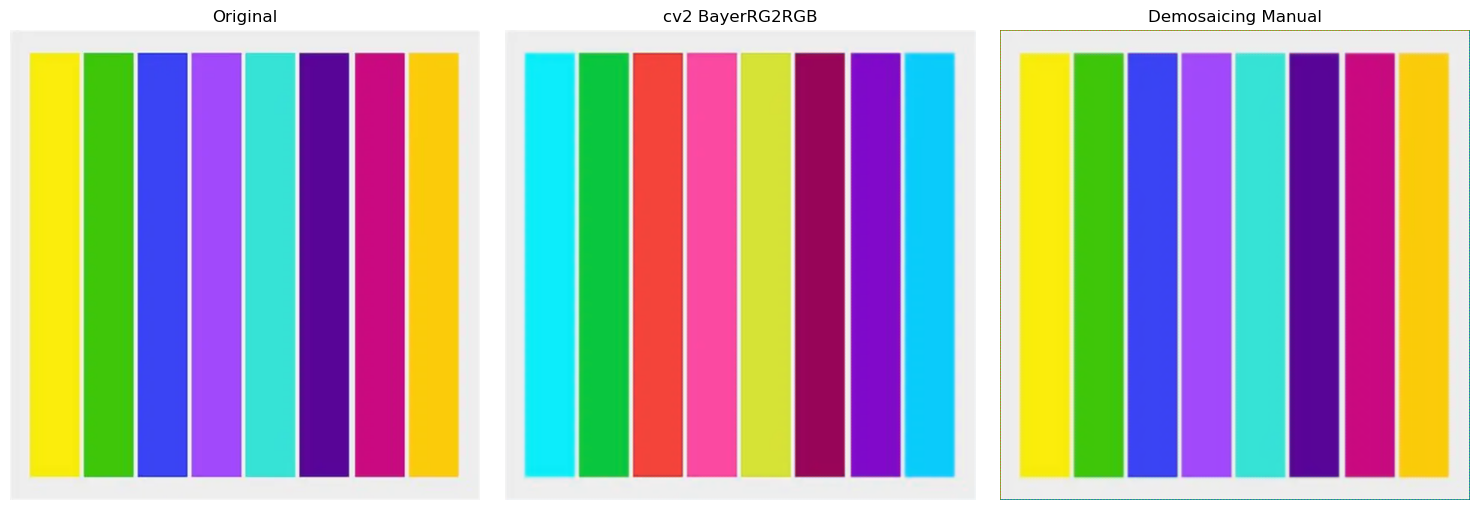

In [12]:
R = np.zeros((h, w), dtype=np.float32)
G = np.zeros((h, w), dtype=np.float32)
B = np.zeros((h, w), dtype=np.float32)

R[0::2, 0::2] = bayer_rg[0::2, 0::2]
G[0::2, 1::2] = bayer_rg[0::2, 1::2]
G[1::2, 0::2] = bayer_rg[1::2, 0::2]
B[1::2, 1::2] = bayer_rg[1::2, 1::2]


for i in range(1, h - 1):
    for j in range(1, w - 1):
    
        vecinos = [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]

        if R[i, j] == 0:  
            suma, cont = 0, 0
            for di, dj in vecinos:
                if R[i+di, j+dj] > 0:
                    suma += R[i+di, j+dj]
                    cont += 1
            if cont > 0:
                R[i, j] = suma / cont

        if G[i, j] == 0:  
            suma, cont = 0, 0
            for di, dj in vecinos:
                if G[i+di, j+dj] > 0:
                    suma += G[i+di, j+dj]
                    cont += 1
            if cont > 0:
                G[i, j] = suma / cont

        if B[i, j] == 0:  
            suma, cont = 0, 0
            for di, dj in vecinos:
                if B[i+di, j+dj] > 0:
                    suma += B[i+di, j+dj]
                    cont += 1
            if cont > 0:
                B[i, j] = suma / cont

img_manual = np.dstack((R, G, B)).astype(np.uint8)

plt.subplot(131)
plt.title('Original')
plt.imshow(img)
plt.axis('off')

plt.subplot(132)
plt.title('cv2 BayerRG2RGB')
plt.imshow(rec_RG)
plt.axis('off')

plt.subplot(133)
plt.title('Demosaicing Manual')
plt.imshow(img_manual)
plt.axis('off')

plt.tight_layout()
plt.show()

## Parte 2 – Transformaciones RGB ↔ YUV

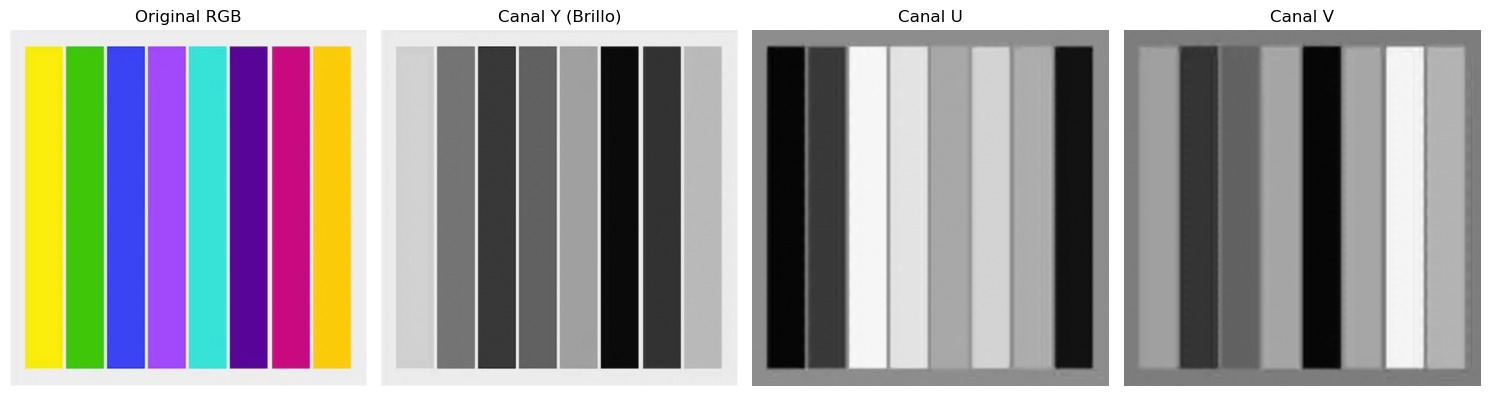

In [4]:
# RGB → YUV
img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)

plt.subplot(141)
plt.title('Original RGB')
plt.imshow(img)
plt.axis('off')

plt.subplot(142)
plt.title('Canal Y (Brillo)')
plt.imshow(img_yuv[:,:,0], cmap='gray')
plt.axis('off')

plt.subplot(143)
plt.title('Canal U')
plt.imshow(img_yuv[:,:,1], cmap='gray')
plt.axis('off')

plt.subplot(144)
plt.title('Canal V')
plt.imshow(img_yuv[:,:,2], cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

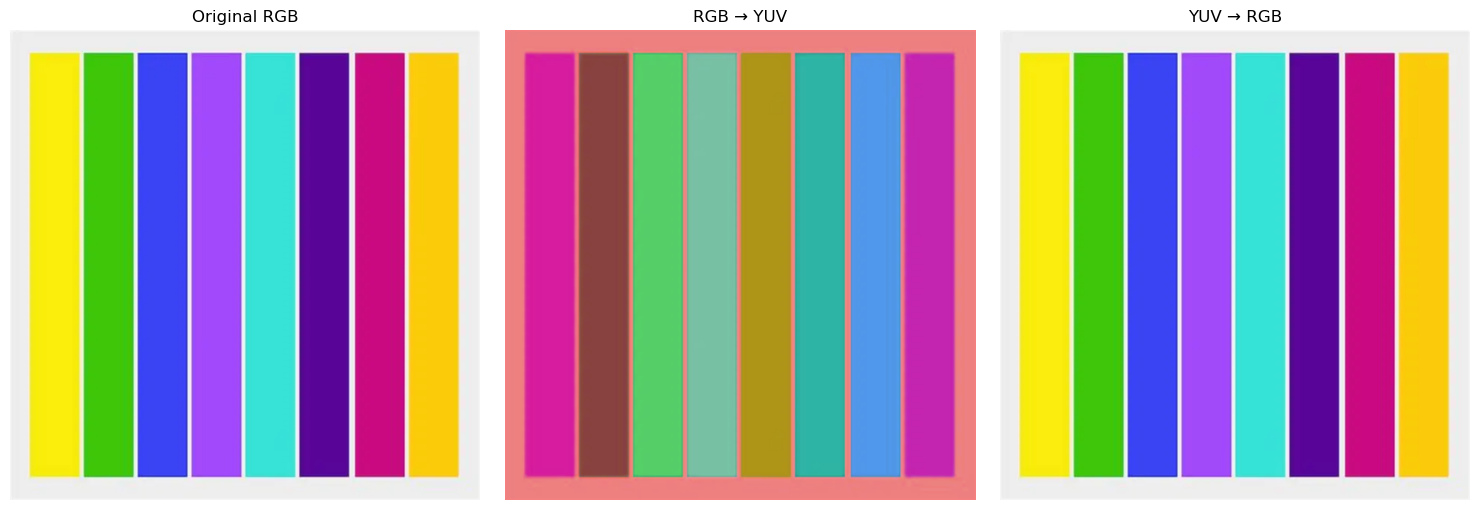

In [ ]:
# YUV → RGB (viceversa)
img_reconstruida = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

plt.subplot(131)
plt.title('Original RGB')
plt.imshow(img)
plt.axis('off')

plt.subplot(132)
plt.title('RGB → YUV')
plt.imshow(img_yuv) # se ve distorsionado: matplotlib lo interpreta como RGB
plt.axis('off')

plt.subplot(133)
plt.title('YUV → RGB')
plt.imshow(img_reconstruida)
plt.axis('off')

plt.tight_layout()
plt.show()